## OPTIMIZACIÓN DE PORTAFOLIO — MODELO DE MARKOWITZ

Fase 5 Frontera eficiente, portafolio de máximo Sharpe, portafolio de mínima varianza y comparación contra el S&P 500.

Importación de librerías

In [1]:
import sys
print(sys.executable)

c:\Users\ofeli\anaconda3\envs\Finance\python.exe


In [13]:
%pip uninstall cvxpy -y
%pip install cvxpy
%pip install --upgrade --no-cache-dir PyPortfolioOpt

Note: you may need to restart the kernel to use updated packages.


  Using cached cvxpy-1.9.2-cp313-cp313-win_amd64.whl.metadata (9.9 kB)
Using cached cvxpy-1.9.2-cp313-cp313-win_amd64.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import cvxpy.constraints  # fuerza a que cp.constraints quede disponible

from pypfopt.expected_returns import mean_historical_return
from pypfopt.risk_models import CovarianceShrinkage, sample_cov
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import plotting


In [3]:
# ============================================================
# CONFIGURACIÓN
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results" / "markowitz"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PRICES_FILE = DATA_DIR / "adjusted_prices.csv"
RETURNS_FILE = DATA_DIR / "daily_returns.csv"

RISK_FREE_RATE = 0.02  # ajustar según el benchmark que uses (p.ej. tasa de CETES o T-Bill)
MAX_WEIGHT = 0.15       # cota máxima por activo, ajustar según lo que justifiques en el informe

benchmark = "^GSPC"

print("Directorio de datos:", DATA_DIR)
print("Directorio de resultados:", RESULTS_DIR)


Directorio de datos: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\data\processed
Directorio de resultados: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\markowitz


## Carga y limpieza de datos

Misma limpieza usada en EDA y en el notebook de features: se descartan filas totalmente vacías en `returns` y se alinean los precios al mismo índice.

In [4]:
prices = pd.read_csv(PRICES_FILE, index_col=0, parse_dates=True)
returns = pd.read_csv(RETURNS_FILE, index_col=0, parse_dates=True)

prices.index.name = "Date"
returns.index.name = "Date"

returns_clean = returns.dropna(how="all")
prices_clean = prices.loc[returns_clean.index]

# Markowitz optimiza solo sobre los activos invertibles, no sobre el benchmark
asset_prices = prices_clean.drop(columns=[benchmark])
asset_returns = returns_clean.drop(columns=[benchmark])

print("Activos invertibles:", asset_prices.shape[1])
print("Periodo:", asset_prices.index.min().date(), "→", asset_prices.index.max().date())


Activos invertibles: 20
Periodo: 2018-01-03 → 2026-08-25


## 1. Retornos esperados y matriz de covarianza

Se calculan dos versiones de la covarianza para comparar: la muestral simple (la que ya tienes del EDA) y la versión con shrinkage de Ledoit-Wolf, más estable cuando el número de activos es grande relativo al histórico disponible.

In [5]:
mu = mean_historical_return(asset_prices)

S_sample = sample_cov(asset_prices)
S_shrink = CovarianceShrinkage(asset_prices).ledoit_wolf()

print("Retornos esperados anualizados (primeros 5):")
mu.head()


Retornos esperados anualizados (primeros 5):


AAPL     0.266843
ADBE     0.049032
AMZN     0.185137
CAT      0.235487
GOOGL    0.240653
dtype: float64

### Comparación visual: covarianza muestral vs. shrinkage

El shrinkage "jala" los valores extremos de la covarianza muestral hacia el promedio general, reduciendo ruido. Se espera ver menos dispersión en la versión con shrinkage.

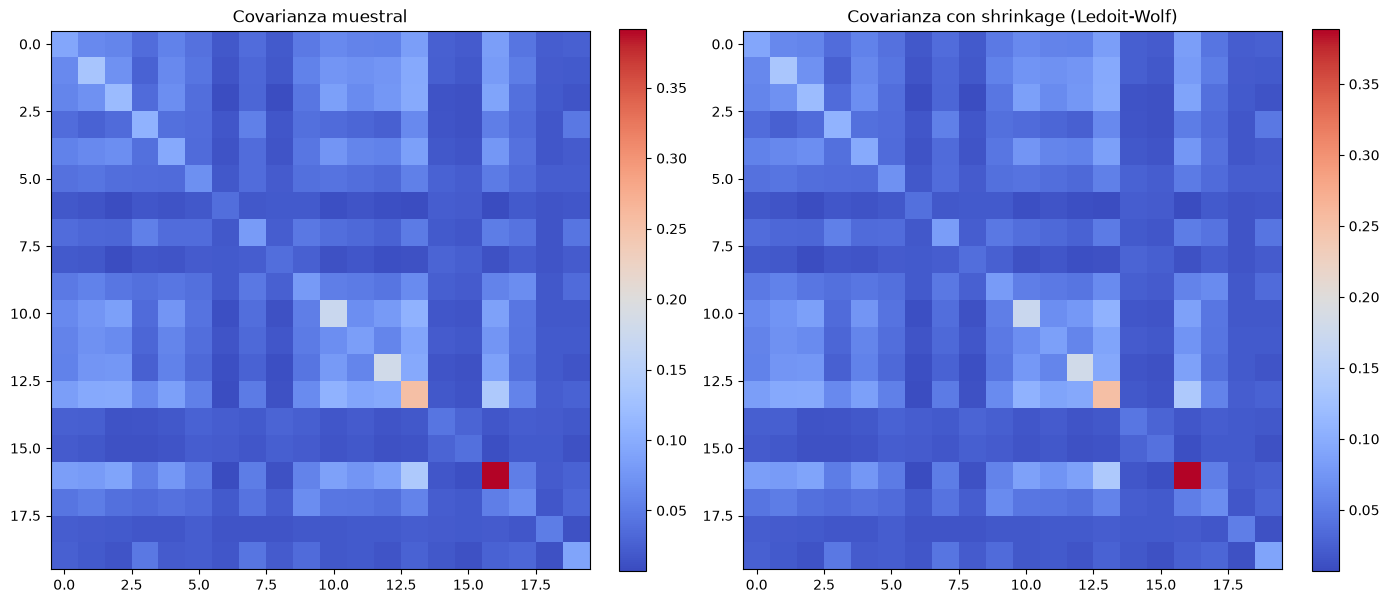

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(S_sample, cmap="coolwarm")
axes[0].set_title("Covarianza muestral")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(S_shrink, cmap="coolwarm")
axes[1].set_title("Covarianza con shrinkage (Ledoit-Wolf)")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "01_covarianza_muestral_vs_shrinkage.png", dpi=300, bbox_inches="tight")
plt.show()


## 2. Frontera eficiente completa

Se grafica la curva completa de frontera eficiente (no solo el punto óptimo), usando la covarianza con shrinkage.

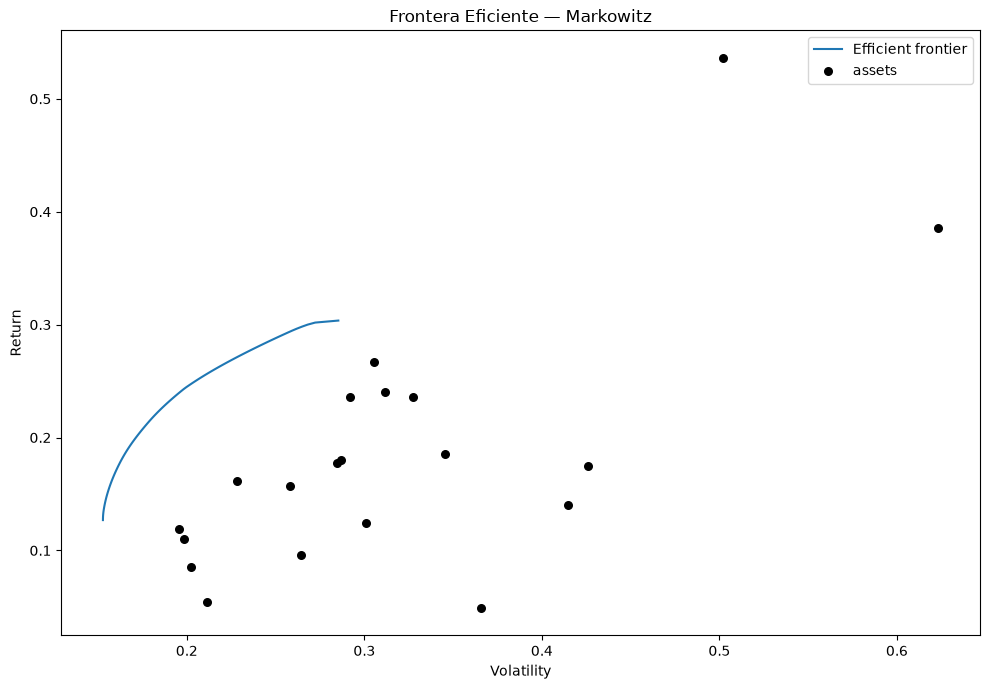

In [7]:
ef_plot = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT))

fig, ax = plt.subplots(figsize=(10, 7))
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)
ax.set_title("Frontera Eficiente — Markowitz")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_frontera_eficiente.png", dpi=300, bbox_inches="tight")
plt.show()


## 3. Portafolio de máximo Sharpe (con restricciones)

Restricción de no ventas en corto (`weight_bounds=(0, ...)`) y cota máxima por activo (`MAX_WEIGHT`), para evitar concentración excesiva en un solo emisor.

In [8]:
ef_max_sharpe = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_max_sharpe.add_constraint(lambda w: w >= 0.01)

raw_weights_max_sharpe = ef_max_sharpe.max_sharpe(risk_free_rate=RISK_FREE_RATE)
weights_max_sharpe = ef_max_sharpe.clean_weights()

perf_max_sharpe = ef_max_sharpe.portfolio_performance(
    verbose=True,
    risk_free_rate=RISK_FREE_RATE
)

pd.Series(weights_max_sharpe).sort_values(ascending=False)


Expected annual return: 23.6%
Annual volatility: 19.8%
Sharpe Ratio: 1.09


NVDA     0.15000
WMT      0.15000
KO       0.14238
CAT      0.12516
JNJ      0.12464
AAPL     0.11595
TSLA     0.04261
GOOGL    0.02926
AMZN     0.01000
ADBE     0.01000
JPM      0.01000
HD       0.01000
MSFT     0.01000
META     0.01000
MA       0.01000
NFLX     0.01000
PG       0.01000
PEP      0.01000
V        0.01000
XOM      0.01000
dtype: float64

## 4. Portafolio de mínima varianza

Segundo punto de referencia: el portafolio con menor riesgo posible dentro de las mismas restricciones, sin considerar el retorno esperado.

In [13]:
ef_min_vol = EfficientFrontier(mu, S_shrink, weight_bounds=(0, MAX_WEIGHT))

# Cota mínima: si un activo entra al portafolio, debe tener al menos 1% de peso
ef_min_vol.add_constraint(lambda w: w >= 0.01)

raw_weights_min_vol = ef_min_vol.min_volatility()
weights_min_vol = ef_min_vol.clean_weights()

perf_min_vol = ef_min_vol.portfolio_performance(
    verbose=True,
    risk_free_rate=RISK_FREE_RATE
)

pd.Series(weights_min_vol).sort_values(ascending=False)


Expected annual return: 13.1%
Annual volatility: 15.4%
Sharpe Ratio: 0.72


PG       0.15000
WMT      0.15000
KO       0.15000
JNJ      0.15000
PEP      0.10368
XOM      0.09749
AMZN     0.04392
CAT      0.02741
NFLX     0.01750
ADBE     0.01000
AAPL     0.01000
HD       0.01000
MSFT     0.01000
META     0.01000
MA       0.01000
JPM      0.01000
GOOGL    0.01000
NVDA     0.01000
V        0.01000
TSLA     0.01000
dtype: float64

## 5. Portafolio equal-weight (benchmark ingenuo)

Tercer punto de comparación: pesos iguales entre todos los activos, sin ninguna optimización. Es el benchmark clásico contra el que hay que superar para justificar que la optimización aporta valor.

In [14]:
n_assets = len(asset_prices.columns)
weights_equal = pd.Series(1 / n_assets, index=asset_prices.columns)

weights_equal.head()


AAPL     0.05
ADBE     0.05
AMZN     0.05
CAT      0.05
GOOGL    0.05
dtype: float64

## 6. Comparación de pesos entre estrategias

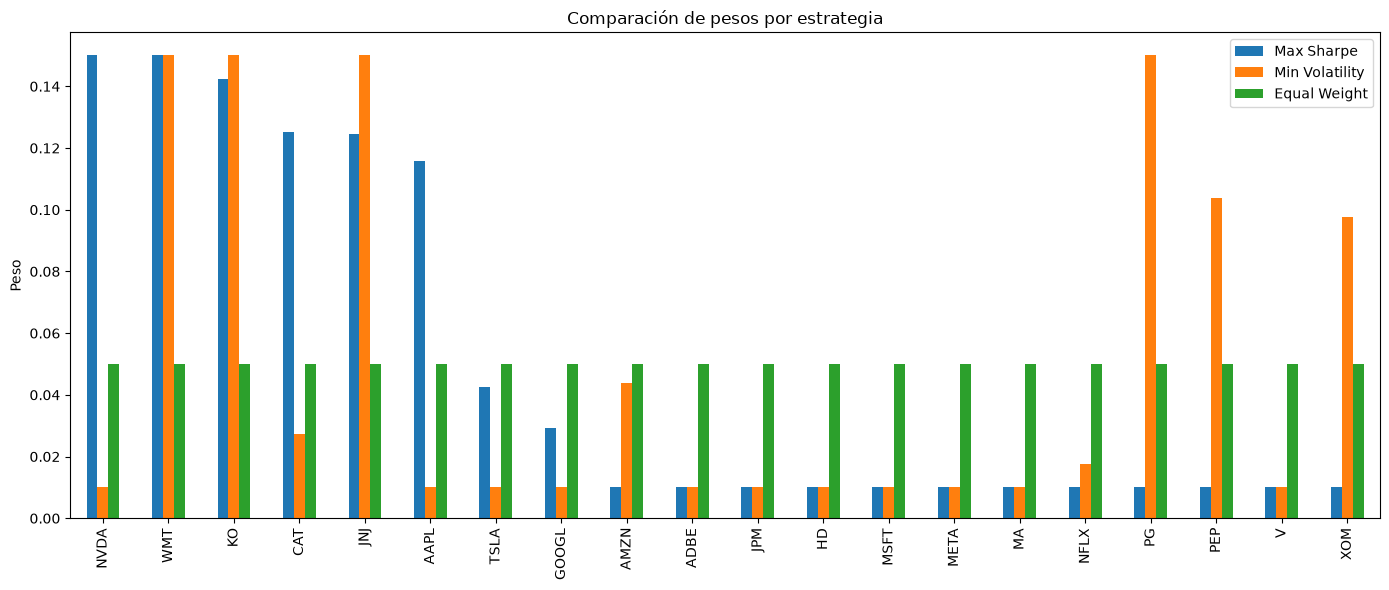

,Max Sharpe,Min Volatility,Equal Weight
NVDA,0.1500,0.0100,0.05
WMT,0.1500,0.1500,0.05
KO,0.1424,0.1500,0.05
CAT,0.1252,0.0274,0.05
JNJ,0.1246,0.1500,0.05
AAPL,0.1160,0.0100,0.05
TSLA,0.0426,0.0100,0.05
GOOGL,0.0293,0.0100,0.05
AMZN,0.0100,0.0439,0.05
ADBE,0.0100,0.0100,0.05


In [15]:
weights_comparison = pd.DataFrame({
    "Max Sharpe": pd.Series(weights_max_sharpe),
    "Min Volatility": pd.Series(weights_min_vol),
    "Equal Weight": weights_equal
}).sort_values("Max Sharpe", ascending=False)

weights_comparison.plot(
    kind="bar",
    figsize=(14, 6),
    title="Comparación de pesos por estrategia"
)
plt.ylabel("Peso")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "03_comparacion_pesos.png", dpi=300, bbox_inches="tight")
plt.show()

weights_comparison.round(4)


## 7. Backtest simple contra el S&P 500

Se construyen las series de retorno acumulado de cada estrategia (pesos fijos, sin rebalanceo — eso se aborda formalmente en la Fase 9) y se comparan contra el benchmark.

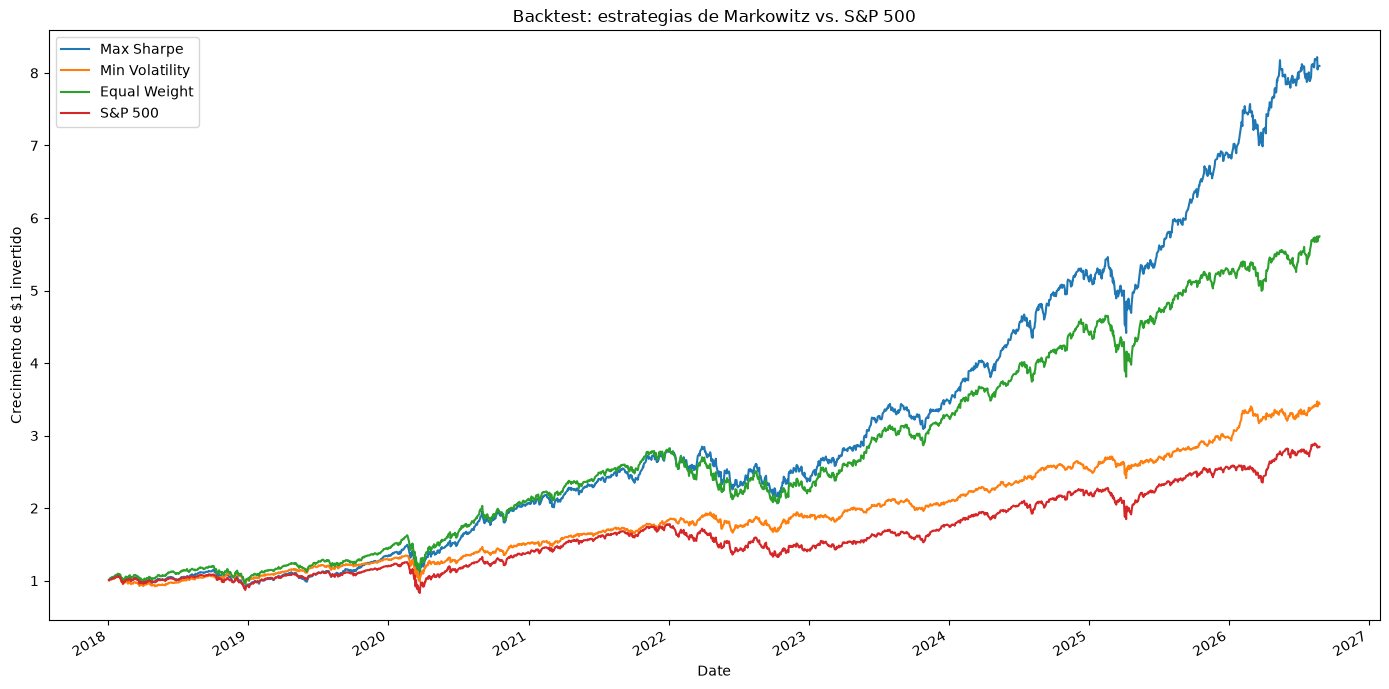

In [16]:
def portfolio_cumulative_return(weights: pd.Series, returns: pd.DataFrame) -> pd.Series:
    aligned_weights = weights.reindex(returns.columns).fillna(0)
    portfolio_returns = (returns * aligned_weights).sum(axis=1)
    return (1 + portfolio_returns).cumprod()

comparison = pd.DataFrame({
    "Max Sharpe": portfolio_cumulative_return(pd.Series(weights_max_sharpe), asset_returns),
    "Min Volatility": portfolio_cumulative_return(pd.Series(weights_min_vol), asset_returns),
    "Equal Weight": portfolio_cumulative_return(weights_equal, asset_returns),
    "S&P 500": (1 + returns_clean[benchmark]).cumprod()
})

comparison.plot(figsize=(14, 7), title="Backtest: estrategias de Markowitz vs. S&P 500")
plt.ylabel("Crecimiento de $1 invertido")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "04_backtest_vs_sp500.png", dpi=300, bbox_inches="tight")
plt.show()


## 8. Tabla resumen de métricas por estrategia

In [17]:
def annualized_metrics(cum_returns: pd.Series, risk_free_rate: float = RISK_FREE_RATE) -> dict:
    daily_returns = cum_returns.pct_change().dropna()
    ann_return = daily_returns.mean() * 252
    ann_vol = daily_returns.std() * np.sqrt(252)
    sharpe = (ann_return - risk_free_rate) / ann_vol
    max_drawdown = (cum_returns / cum_returns.cummax() - 1).min()
    return {
        "Retorno anualizado": ann_return,
        "Volatilidad anualizada": ann_vol,
        "Sharpe Ratio": sharpe,
        "Máximo Drawdown": max_drawdown
    }

summary = pd.DataFrame({
    col: annualized_metrics(comparison[col]) for col in comparison.columns
}).T

summary.round(4)


,Retorno anualizado,Volatilidad anualizada,Sharpe Ratio,Máximo Drawdown
Max Sharpe,0.2612,0.1991,1.2113,-0.2816
Min Volatility,0.1546,0.1544,0.8718,-0.2649
Equal Weight,0.2224,0.2025,0.9997,-0.2998
S&P 500,0.1392,0.1922,0.6201,-0.3392


## 9. Guardar resultados

In [18]:
pd.Series(weights_max_sharpe).to_csv(RESULTS_DIR / "weights_max_sharpe.csv")
pd.Series(weights_min_vol).to_csv(RESULTS_DIR / "weights_min_volatility.csv")
comparison.to_csv(RESULTS_DIR / "backtest_comparison.csv")
summary.to_csv(RESULTS_DIR / "summary_metrics.csv")

print("Resultados guardados en:", RESULTS_DIR)


Resultados guardados en: c:\Users\ofeli\Documents\GitHub\Portafolio_investigacion\results\markowitz
